In [1]:
!pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable


In [7]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [8]:
class1_path = "dataset/class1"
class2_path = "dataset/class2"

class1_images = [
    f for f in os.listdir(class1_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

class2_images = [
    f for f in os.listdir(class2_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Class 1 (Healthy) images:", len(class1_images))
print("Class 2 (Unhealthy) images:", len(class2_images))

Class 1 (Healthy) images: 5
Class 2 (Unhealthy) images: 5


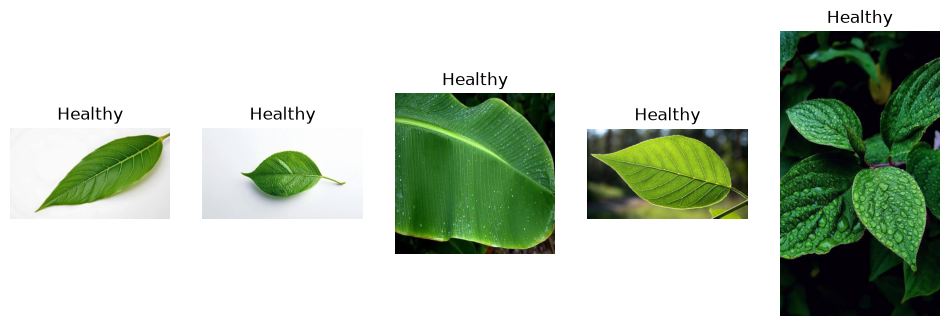

In [9]:
plt.figure(figsize=(12, 6))

for i, file in enumerate(class1_images[:5]):
    img = cv2.imread(os.path.join(class1_path, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Healthy")

plt.show()

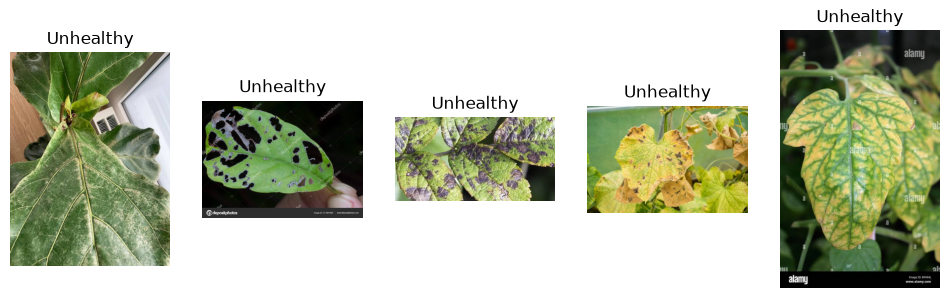

In [10]:
plt.figure(figsize=(12, 6))

for i, file in enumerate(class2_images[:5]):
    img = cv2.imread(os.path.join(class2_path, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Unhealthy")

plt.show()

In [11]:
def extract_features(image_path):
    img = cv2.imread(image_path)

    if img is None:
        return None

    img = cv2.resize(img, (100, 100))

    blue, green, red = cv2.split(img)

    features = [
        np.mean(red),
        np.mean(green),
        np.mean(blue),
        np.std(red),
        np.std(green),
        np.std(blue)
    ]

    return features

In [12]:
X = []
y = []

# Class 1 = Healthy
for file in class1_images:
    path = os.path.join(class1_path, file)
    features = extract_features(path)

    if features is not None:
        X.append(features)
        y.append(1)

# Class 2 = Unhealthy
for file in class2_images:
    path = os.path.join(class2_path, file)
    features = extract_features(path)

    if features is not None:
        X.append(features)
        y.append(2)

X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)
print("Labels:", y)

Feature shape: (10, 6)
Labels: [1 1 1 1 1 2 2 2 2 2]


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 6
Testing samples: 4


In [14]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [15]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Actual:", y_test)
print("Predicted:", y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Actual: [1 1 2 2]
Predicted: [1 2 2 2]
Accuracy: 75.00%


In [16]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Healthy", "Unhealthy"]
))

              precision    recall  f1-score   support

     Healthy       1.00      0.50      0.67         2
   Unhealthy       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



In [17]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1 1]
 [0 2]]


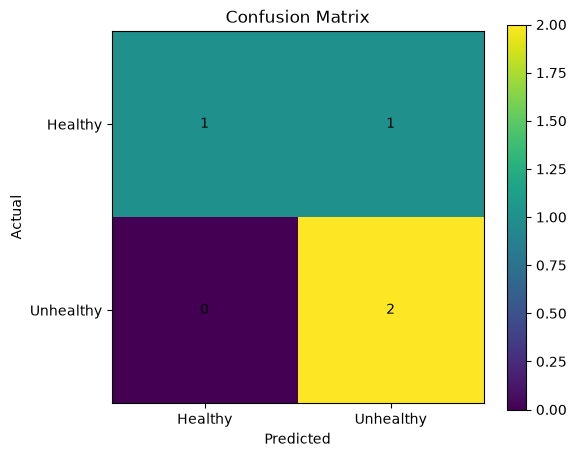

In [18]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Healthy", "Unhealthy"])
plt.yticks([0, 1], ["Healthy", "Unhealthy"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

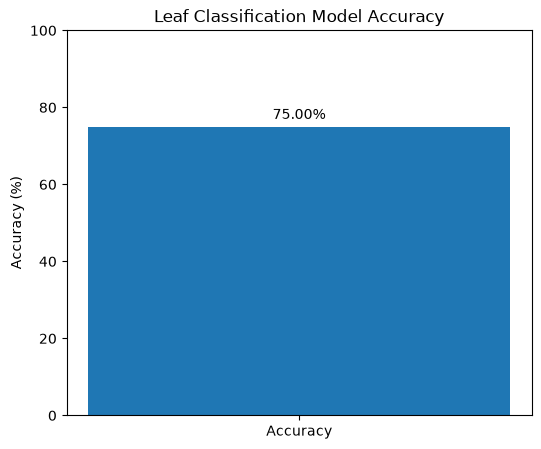

In [19]:
plt.figure(figsize=(6, 5))

plt.bar(["Accuracy"], [accuracy * 100])

plt.ylim(0, 100)
plt.ylabel("Accuracy (%)")
plt.title("Leaf Classification Model Accuracy")

plt.text(
    0,
    accuracy * 100 + 2,
    f"{accuracy * 100:.2f}%",
    ha="center"
)

plt.show()

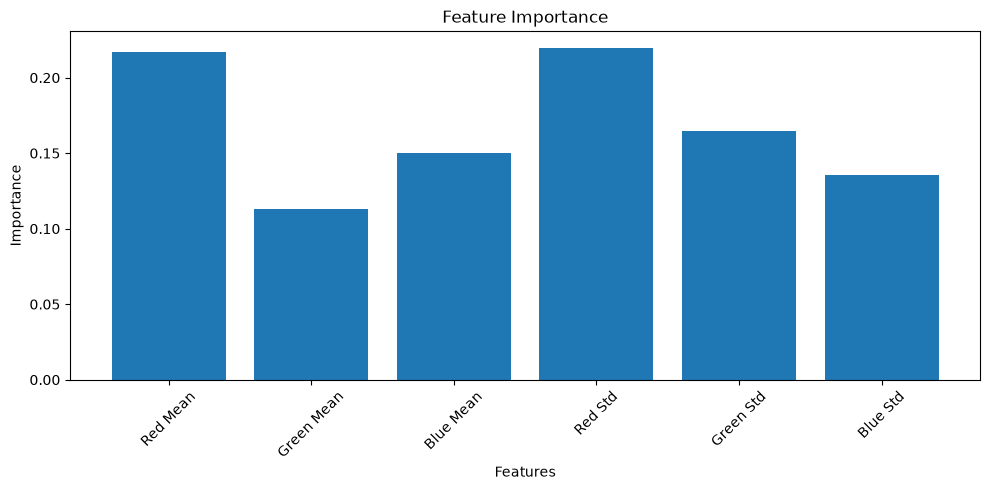

In [20]:
feature_names = [
    "Red Mean",
    "Green Mean",
    "Blue Mean",
    "Red Std",
    "Green Std",
    "Blue Std"
]

importance = model.feature_importances_

plt.figure(figsize=(10, 5))

plt.bar(feature_names, importance)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
import joblib

joblib.dump(model, "leaf_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [22]:
test_image_path = "test_leaf.png"

features = extract_features(test_image_path)

if features is not None:

    prediction = model.predict([features])[0]

    if prediction == 1:
        print("Prediction: Class 1")
        print("Result: Healthy Leaf")

    else:
        print("Prediction: Class 2")
        print("Result: Unhealthy Leaf")

else:
    print("Image not found!")

Prediction: Class 1
Result: Healthy Leaf


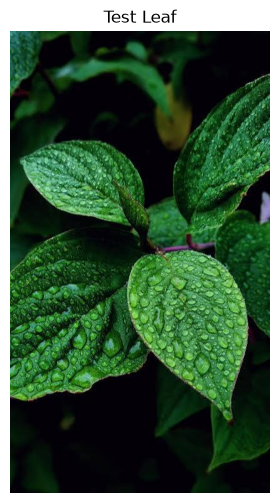

In [23]:
img = cv2.imread(test_image_path)

if img is not None:

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Test Leaf")
    plt.show()

In [24]:
print("===================================")
print("     PLANT LEAF CLASSIFICATION")
print("===================================")

print("Class 1 : Healthy Leaf")
print("Class 2 : Unhealthy Leaf")

print("Total Images :", len(X))
print("Training Images :", len(X_train))
print("Testing Images :", len(X_test))

print("Model : Random Forest")
print(f"Accuracy : {accuracy * 100:.2f}%")

print("===================================")
print("Project Completed Successfully!")
print("===================================")

     PLANT LEAF CLASSIFICATION
Class 1 : Healthy Leaf
Class 2 : Unhealthy Leaf
Total Images : 10
Training Images : 6
Testing Images : 4
Model : Random Forest
Accuracy : 75.00%
Project Completed Successfully!
